# CodeAlpha Internship — Project 3
# Handwritten Character Recognition

## Objective

The objective of this project is to develop a deep learning model capable of recognizing handwritten digits from 0 to 9 using the MNIST dataset.

A Convolutional Neural Network (CNN) is used because it is well suited for image classification and can automatically learn important visual patterns from handwritten images.

## Project Workflow

1. Load the MNIST dataset
2. Explore and visualize the data
3. Preprocess the images
4. Build a CNN model
5. Train the model
6. Evaluate model performance
7. Analyze predictions using a confusion matrix
8. Visualize sample predictions
9. Save results and visualizations

Import libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
print("Libraries imported successfully.")

Libraries imported successfully.


Load MNIST

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


Dataset overview

In [ ]:
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))
print("Image dimensions:", X_train.shape[1:])
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("\nPixel value range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Number of training samples: 60000
Number of testing samples: 10000
Image dimensions: (28, 28)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]

Pixel value range:
Minimum: 0
Maximum: 255


Visualize handwritten digits

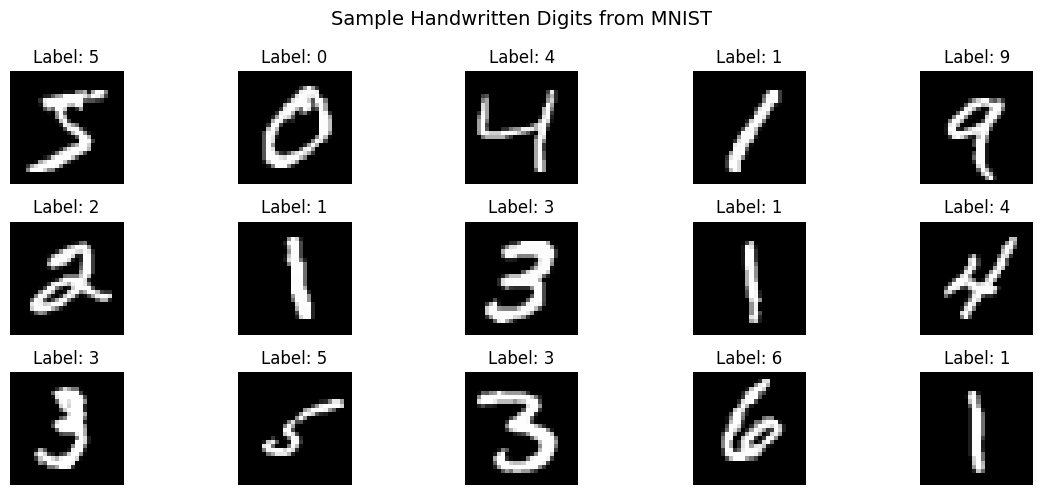

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Handwritten Digits from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
# Normalize pixel values from 0–255 to 0–1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
# Add channel dimension for CNN input
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Pixel value range:", X_train.min(), "to", X_train.max())

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


Build the CNN

## Convolutional Neural Network

A Convolutional Neural Network (CNN) is used to learn spatial patterns in handwritten digit images.

The model consists of:
- Convolutional layers for feature extraction
- Max-pooling layers for dimensionality reduction
- Flatten layer to convert feature maps into a vector
- Dense layers for classification
- Softmax output layer for predicting one of the 10 digit classes

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


Train the CNN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.9215 - loss: 0.2565 - val_accuracy: 0.9812 - val_loss: 0.0715
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.9769 - loss: 0.0754 - val_accuracy: 0.9883 - val_loss: 0.0435
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9883 - val_loss: 0.0366
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9863 - loss: 0.0435 - val_accuracy: 0.9892 - val_loss: 0.0340
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9890 - loss: 0.0363 - val_accuracy: 0.9908 - val_loss: 0.0316
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9906 - loss: 0.0302 - val_accuracy: 0.9912 - val_loss: 0.0280
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9917 - val_loss: 0.0309
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9925 - loss: 0.0225 -

Test the trained CNN

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9908 - loss: 0.0264
Test Loss: 0.0264
Test Accuracy: 99.0800%


Predictions and Classification Report

In [ ]:
# Generate class probabilities and predictions
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 10000


In [ ]:
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(i) for i in range(10)],
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

           0     0.9929    0.9949    0.9939       980
           1     0.9895    0.9974    0.9934      1135
           2     0.9913    0.9922    0.9918      1032
           3     0.9862    0.9921    0.9891      1010
           4     0.9879    0.9980    0.9929       982
           5     0.9932    0.9821    0.9876       892
           6     0.9927    0.9906    0.9916       958
           7     0.9883    0.9903    0.9893      1028
           8     0.9938    0.9867    0.9902       974
           9     0.9930    0.9822    0.9875      1009

    accuracy                         0.9908     10000
   macro avg     0.9909    0.9906    0.9907     10000
weighted avg     0.9908    0.9908    0.9908     10000



Confusion Matrix

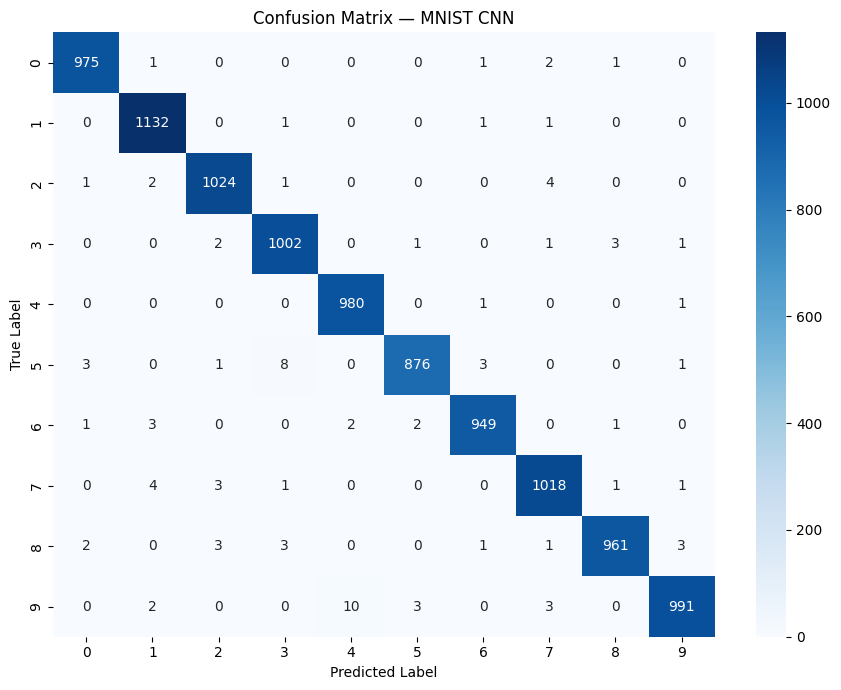

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title("Confusion Matrix — MNIST CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Training & Validation Curves

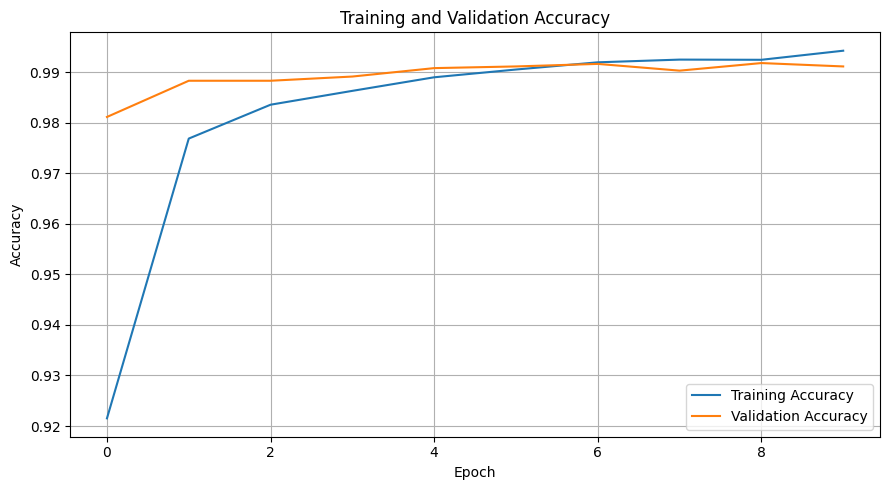

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

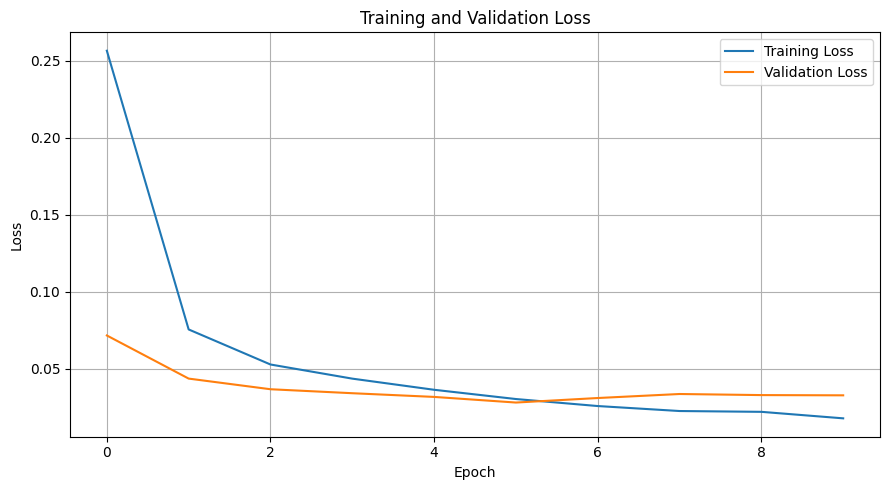

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Display correct and incorrect predictions

In [ ]:
# Identify correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]
print("Correct predictions:", len(correct_indices))
print("Incorrect predictions:", len(incorrect_indices))
print(f"Overall accuracy: {len(correct_indices) / len(y_test):.4%}")

Correct predictions: 9908
Incorrect predictions: 92
Overall accuracy: 99.0800%


Correct predictions

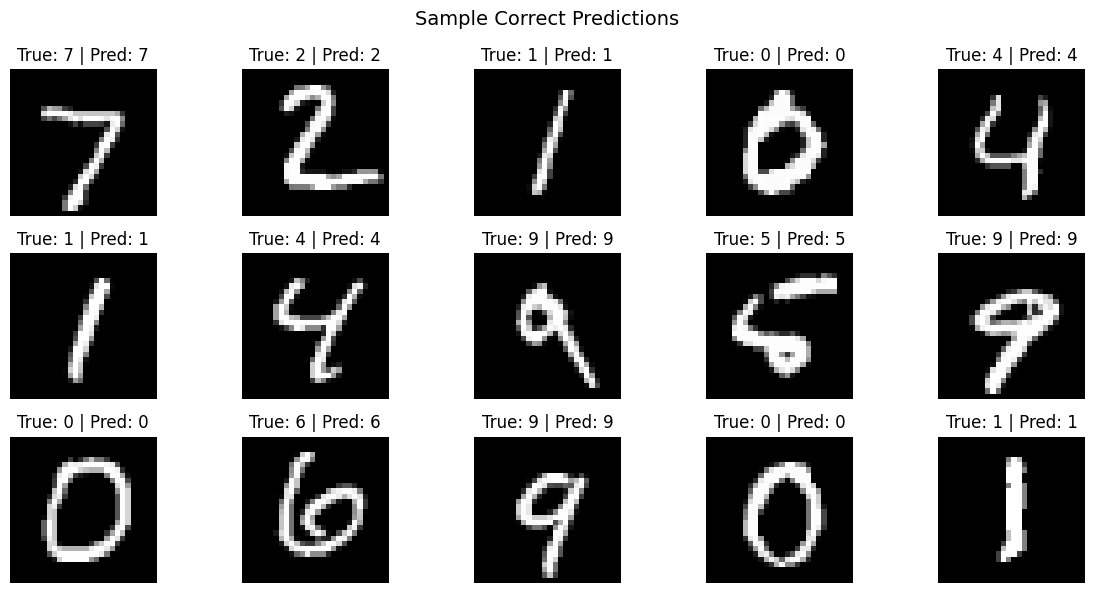

In [ ]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(correct_indices[:15]):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
    plt.axis("off")
plt.suptitle("Sample Correct Predictions", fontsize=14)
plt.tight_layout()
plt.show()

Incorrect predictions

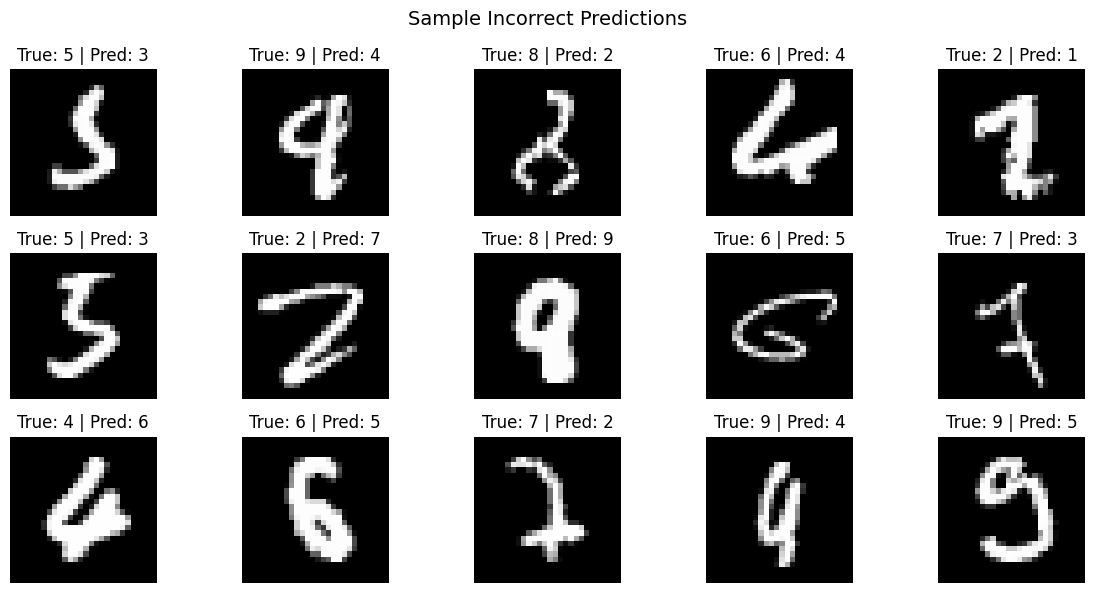

In [ ]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(incorrect_indices[:15]):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
    plt.axis("off")
plt.suptitle("Sample Incorrect Predictions", fontsize=14)
plt.tight_layout()
plt.show()

Prediction confidence

In [ ]:
confidence = np.max(y_prob, axis=1)
print(f"Average prediction confidence: {confidence.mean():.4%}")
print(f"Minimum prediction confidence: {confidence.min():.4%}")
print(f"Maximum prediction confidence: {confidence.max():.4%}")

Average prediction confidence: 99.3735%
Minimum prediction confidence: 34.7886%
Maximum prediction confidence: 100.0000%


Save Resukts

In [ ]:
import os
os.makedirs("results", exist_ok=True)
# 1. Save training history
history_df = pd.DataFrame(history.history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"
history_df.to_csv("results/training_history.csv")

# 2. Save confusion matrix
pd.DataFrame(
    cm,
    index=[f"True_{i}" for i in range(10)],
    columns=[f"Predicted_{i}" for i in range(10)]
).to_csv("results/confusion_matrix.csv")
# 3. Save classification report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in range(10)],
    output_dict=True
)
pd.DataFrame(report_dict).transpose().to_csv(
    "results/classification_report.csv"
)
# 4. Save sample predictions
sample_indices = np.arange(20)
sample_predictions = pd.DataFrame({
    "sample_index": sample_indices,
    "actual_digit": y_test[sample_indices],
    "predicted_digit": y_pred[sample_indices],
    "confidence": confidence[sample_indices]
})
sample_predictions.to_csv(
    "results/sample_predictions.csv",
    index=False
)
# 5. Save accuracy summary
summary = pd.DataFrame({
    "metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],
    "value": [
        history.history["accuracy"][-1],
        history.history["val_accuracy"][-1],
        test_accuracy,
        report_dict["macro avg"]["precision"],
        report_dict["macro avg"]["recall"],
        report_dict["macro avg"]["f1-score"]
    ]
})
summary.to_csv("results/model_performance.csv", index=False)
print("Results saved successfully.")

Results saved successfully.


Real-World Handwritten Digit Testing

## Real-World Handwritten Digit Testing
In this section, the trained CNN model is tested on a handwritten digit image uploaded by the user. The uploaded image is converted to grayscale and preprocessed to match the MNIST input format of 28 × 28 pixels. The model then predicts the handwritten digit and displays the predicted class along with its confidence score.

The predicted digit can be compared with the actual digit entered by the user to verify whether the model correctly recognizes the handwritten character.

Purpose:

Test the trained CNN model using a real handwritten digit.
Apply image preprocessing before prediction.
Display the predicted digit and confidence score.
Compare the prediction with the actual digit.
Demonstrate the practical application of handwritten character recognition.

Saving 0.jpeg to 0.jpeg


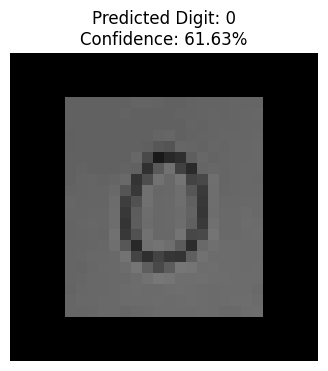

REAL-WORLD HANDWRITTEN DIGIT TEST
Image: 0.jpeg
Predicted Digit: 0
Confidence: 61.63%
Enter the actual digit you wrote: 0
Actual Digit: 0
Result: CORRECT


In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import io
import numpy as np
import matplotlib.pyplot as plt
# Upload one handwritten digit image
uploaded = files.upload()
file_name = next(iter(uploaded))
# Read image
image = Image.open(
    io.BytesIO(uploaded[file_name])
).convert("L")
# Convert to numpy array
img = np.array(image)
# Convert to MNIST-style: white digit on black background
if img.mean() > 127:
    img = 255 - img
# Find handwritten digit
threshold = 50
mask = img > threshold
if not mask.any():
    raise ValueError("Digit could not be detected. Please upload a clearer image.")
# Crop around digit
rows, cols = np.where(mask)
y1, y2 = rows.min(), rows.max()
x1, x2 = cols.min(), cols.max()
cropped = img[y1:y2 + 1, x1:x2 + 1]
# Convert to PIL
cropped = Image.fromarray(cropped.astype("uint8"))
# Resize while maintaining shape
w, h = cropped.size
scale = min(20 / w, 20 / h)
new_w = max(1, int(w * scale))
new_h = max(1, int(h * scale))
cropped = cropped.resize(
    (new_w, new_h),
    Image.Resampling.LANCZOS
)
# Create 28x28 MNIST-style image
canvas = np.zeros((28, 28), dtype=np.uint8)
x_offset = (28 - new_w) // 2
y_offset = (28 - new_h) // 2
canvas[
    y_offset:y_offset + new_h,
    x_offset:x_offset + new_w
] = np.array(cropped)
# Normalize
input_image = canvas.astype("float32") / 255.0
# CNN input
model_input = input_image.reshape(1, 28, 28, 1)
# Predict
probabilities = model.predict(
    model_input,
    verbose=0
)[0]
predicted_digit = int(np.argmax(probabilities))
confidence = float(np.max(probabilities))
# Display processed image
plt.figure(figsize=(4, 4))
plt.imshow(
    input_image,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title(
    f"Predicted Digit: {predicted_digit}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.show()
# Print result
print("=" * 45)
print("REAL-WORLD HANDWRITTEN DIGIT TEST")
print("=" * 45)
print(f"Image: {file_name}")
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2%}")
print("=" * 45)
# Enter actual digit
actual_digit = int(
    input("Enter the actual digit you wrote: ")
)
print(
    f"Actual Digit: {actual_digit}"
)
if actual_digit == predicted_digit:
    print("Result: CORRECT")
else:
    print("Result: INCORRECT")

Save the results

Accuracy graph

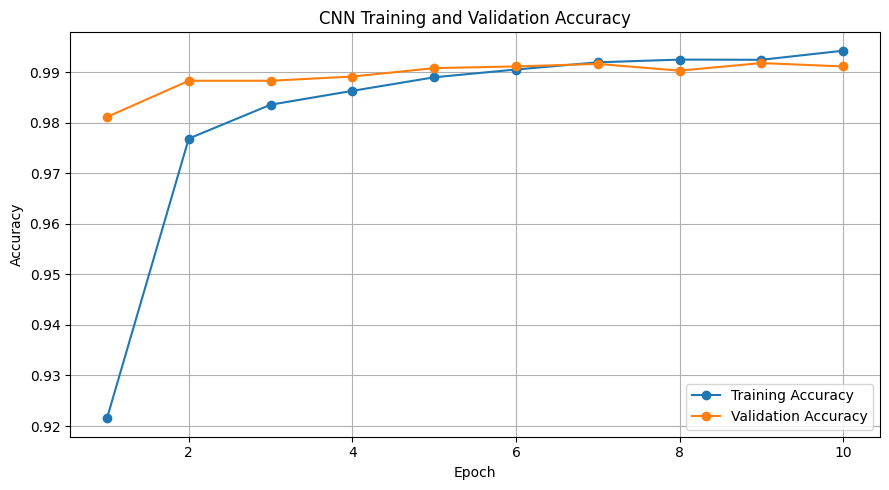

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(history.history["accuracy"]) + 1),
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    range(1, len(history.history["val_accuracy"]) + 1),
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "results/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Loss graph

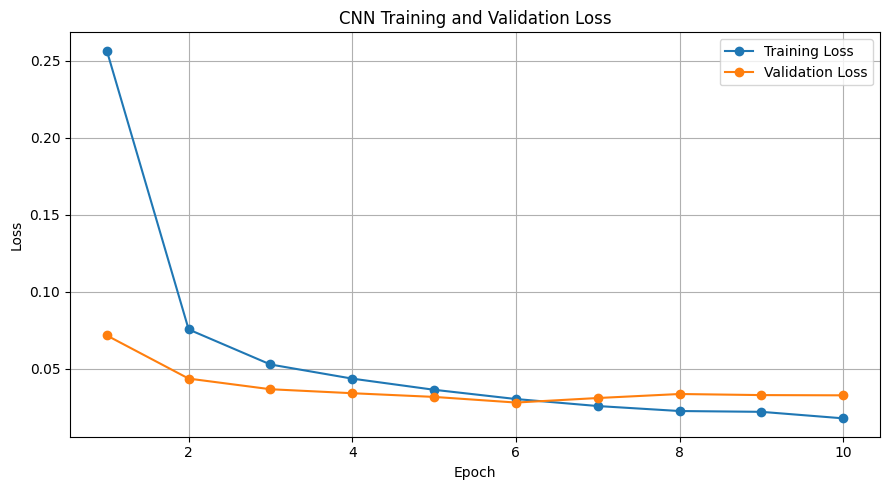

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(history.history["loss"]) + 1),
    history.history["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    range(1, len(history.history["val_loss"]) + 1),
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "results/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Confusion matrix image

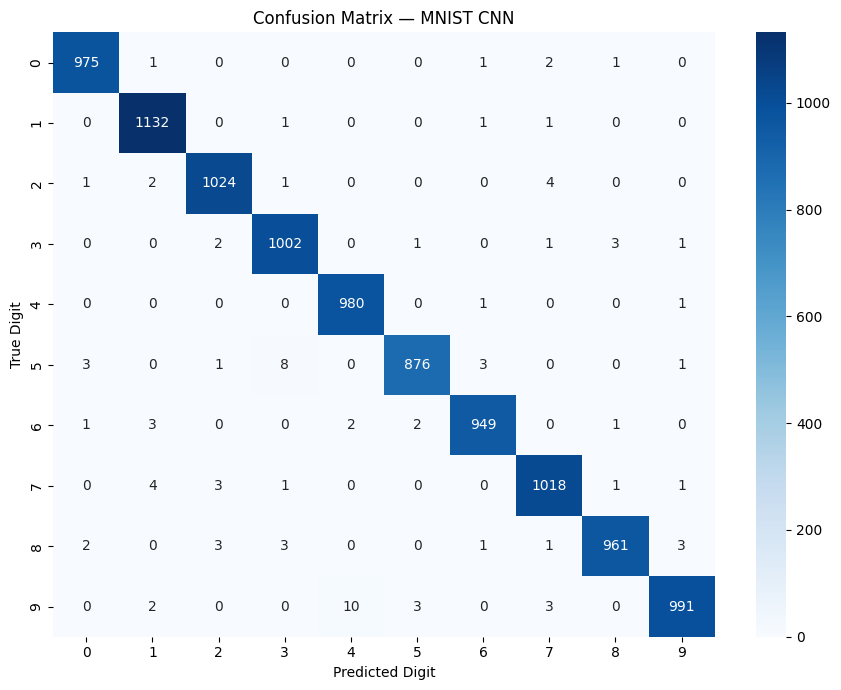

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title("Confusion Matrix — MNIST CNN")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout()
plt.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
import os
print("Files inside results/:")
for file in sorted(os.listdir("results")):
    print("✓", file)

Files inside results/:
✓ classification_report.csv
✓ confusion_matrix.csv
✓ confusion_matrix.png
✓ model_performance.csv
✓ sample_predictions.csv
✓ training_history.csv
✓ training_validation_accuracy.png
✓ training_validation_loss.png


In [ ]:
requirements = """numpy
pandas
matplotlib
seaborn
scikit-learn
tensorflow
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)
print("requirements.txt created successfully.")

requirements.txt created successfully.


In [ ]:
with open("requirements.txt", "r") as f:
    print(f.read())

numpy
pandas
matplotlib
seaborn
scikit-learn
tensorflow

